 # AI for Good — Minor ADSAI

 ## Week 5: Machine Learning Basics



 For four weeks **you** wrote every rule. This week the computer writes the rules — by learning from examples. You will train and test your first real machine-learning models with **scikit-learn**, the standard Python ML toolkit, on a **real medical dataset**.



 **Theme of the week:** *AI that assists, never replaces*. We use a real breast-cancer screening dataset to ask the question that matters more than accuracy: **when a model is wrong, who gets hurt?**



 > **Setup:** this week needs `scikit-learn` (already installed with Anaconda). Everything runs offline on datasets that ship with scikit-learn — no downloads.

 > **Last section (16:45):** Friday's tool, done properly — the data-science recipe on real, messy data. It downloads one small file (the Titanic passenger list); `titanic.csv` next to this notebook is the no-wifi backup.



 ---

 ### 🧠 First: what *is* machine learning?



 Until now, **you** wrote every rule by hand:



 ```python

 if score >= 55:

     print("pass")

 ```



 That works when *you* know the rule. But what is the rule for *"is this tumour dangerous?"* or *"is this email spam?"* Nobody can write that rule by hand — there are too many tiny factors.



 **Machine learning flips it around.** Instead of writing the rule, you show the computer many **examples that already have the answer**, and it finds the pattern itself:



 - **features** (`X`) — the measurements that describe each example (tumour size, texture, …)

 - **label** (`y`) — the known answer for each example (`malignant` or `benign`)



 The model **learns** the relationship `X → y`, then **predicts** `y` for new examples it has never seen. This is called **supervised learning**.



 #### Two golden rules

 1. **Split your data.** Train on one part, then *test* on another part the model never saw — like studying from practice questions, then sitting a real exam. Testing on the training data is cheating (the model could just memorise).

 2. **Garbage in, garbage out.** The model only knows the examples you gave it. *(Remember Week 3 & 4: who is missing from the data?)* A model trained on one hospital's patients may fail badly on another's.



 Every scikit-learn model uses the **same four steps**, no matter which algorithm:



 ```python

 model = SomeModel()          # 1. choose

 model.fit(X_train, y_train)  # 2. learn from examples

 preds = model.predict(X_test)# 3. predict on unseen data

 accuracy_score(y_test, preds)# 4. check

 ```

 ---

 ## Learning Wave 1 — The Machine Learning Workflow (KNN)



 Your first algorithm is the most intuitive one: **K-Nearest Neighbours (KNN)**.



 > **Intuition:** to decide what a new patient is, look at the **k** most similar patients you already know the answer for, and take a **majority vote**. *"You are like your closest neighbours."* If 4 of the 5 nearest patients had benign tumours, KNN predicts benign.



 ### Exercise 1: Train your first model

 ⏱ **15 minutes** | Slide 7



 **Steps:**

 1. Load the real dataset: `from sklearn.datasets import load_breast_cancer`. Get `X = data.data` and `y = data.target`.

 2. Explore: how many patients? how many measurements per patient? What are the class names (`data.target_names`)?

 3. Split into train/test with `train_test_split(X, y, test_size=0.25, random_state=42)`.

 4. Create a `KNeighborsClassifier(n_neighbors=5)`, `fit()` it on the training data.

 5. `predict()` on the test data and print the `accuracy_score`.

 6. Print the prediction vs the real answer for the first test patient.

In [11]:
# Exercise 1: Train your first model
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1 & 2. Load the data and explore it (X = data.data, y = data.target)
data = load_breast_cancer()
X = data.data
y = data.target

print(f"Number of patients (rows): {X.shape[0]}")
print(f"Number of measurements per patient (features): {X.shape[1]}")
print(f"Class names: {data.target_names} (where 0 = {data.target_names[0]}, 1 = {data.target_names[1]})")

# 3. Split into train and test (test_size=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(f"Training set: {X_train.shape[0]} patients | Test set: {X_test.shape[0]} patients")

# 4. Create KNeighborsClassifier(n_neighbors=5) and fit it on the training data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 5. Predict on the test data and print the accuracy
predictions = knn.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"KNN (k=5) Test Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")

# 6. Print prediction vs actual for the first test patient
first_patient_pred = predictions[0]
first_patient_actual = y_test[0]
print(f"\nFirst test patient:")
print(f"  Predicted: {first_patient_pred} ({data.target_names[first_patient_pred]})")
print(f"  Actual:    {first_patient_actual} ({data.target_names[first_patient_actual]})")
print(f"  Correct?   {first_patient_pred == first_patient_actual}")


Number of patients (rows): 569
Number of measurements per patient (features): 30
Class names: ['malignant' 'benign'] (where 0 = malignant, 1 = benign)
Training set: 426 patients | Test set: 143 patients
KNN (k=5) Test Accuracy: 0.9650 (96.50%)

First test patient:
  Predicted: 1 (benign)
  Actual:    1 (benign)
  Correct?   True


 ---

 ## Learning Wave 2 — Different Models, Same Workflow



 The beauty of scikit-learn: **swap the model, keep the four steps.** Let's try two more famous algorithms on the *same* split and see which wins.



 - **Logistic Regression** — draws the best boundary line between the two classes (despite the name, it *classifies*).

 - **Decision Tree** — asks a series of yes/no questions (`is texture > 20?`). You can read it like a flowchart, which makes it easy to explain to a doctor.



 You will also meet the central danger of ML: **overfitting** — a model that *memorises* the training data and then fails on new data. The tell-tale sign is high **train** accuracy but low **test** accuracy.



 ### Exercise 2: Compare three models

 ⏱ **15 minutes** | Slide 10



 **Steps:**

 1. Train a `LogisticRegression(max_iter=5000)` on the same split; print its test accuracy.

 2. Train a `DecisionTreeClassifier(max_depth=3, random_state=42)`; print its test accuracy.

 3. Now train a tree with **no depth limit** and compare its **train** accuracy to its **test** accuracy — what do you see?

 4. A tree is readable: use `feature_importances_` to print which measurement it relies on most.

In [12]:
# Exercise 2: Compare three models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# 1. Train LogisticRegression(max_iter=5000) and print test accuracy
log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_train, y_train)
log_reg_acc = accuracy_score(y_test, log_reg.predict(X_test))
print(f"1. Logistic Regression Test Accuracy: {log_reg_acc:.4f}")

# 2. Train DecisionTreeClassifier(max_depth=3, random_state=42) and print test accuracy
shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
shallow_tree.fit(X_train, y_train)
shallow_tree_acc = accuracy_score(y_test, shallow_tree.predict(X_test))
print(f"2. Decision Tree (max_depth=3) Test Accuracy: {shallow_tree_acc:.4f}")

# 3. Train a tree with NO depth limit; compare its TRAIN vs TEST accuracy (overfitting!)
deep_tree = DecisionTreeClassifier(random_state=42)
deep_tree.fit(X_train, y_train)
deep_train_acc = accuracy_score(y_train, deep_tree.predict(X_train))
deep_test_acc = accuracy_score(y_test, deep_tree.predict(X_test))
print(f"3. Deep Tree (no limit):")
print(f"   Train Accuracy: {deep_train_acc:.4f} (100% memorised)")
print(f"   Test Accuracy:  {deep_test_acc:.4f}")
print(f"   Gap: {deep_train_acc - deep_test_acc:.4f} -> This performance drop shows classic overfitting!")

# 4. Print the measurement the shallow tree relies on most (feature_importances_)
importances = shallow_tree.feature_importances_
top_feature_idx = np.argmax(importances)
print(f"\n4. Most important measurement for the shallow tree:")
print(f"   Feature: '{data.feature_names[top_feature_idx]}'")
print(f"   Importance score: {importances[top_feature_idx]:.4f}")


1. Logistic Regression Test Accuracy: 0.9650
2. Decision Tree (max_depth=3) Test Accuracy: 0.9580
3. Deep Tree (no limit):
   Train Accuracy: 1.0000 (100% memorised)
   Test Accuracy:  0.9510
   Gap: 0.0490 -> This performance drop shows classic overfitting!

4. Most important measurement for the shallow tree:
   Feature: 'mean concave points'
   Importance score: 0.7929


 ---

 ## Learning Wave 3 — Accuracy Lies: Looking at the Errors



 "95% accurate" sounds great. But **accuracy treats every mistake as equal — and in the real world, they are not.** Telling a healthy person they might be sick (a *false alarm*) is upsetting. Telling a sick person they are healthy (a *dangerous miss*) can be fatal.



 A **confusion matrix** breaks the predictions into four boxes so you can see *which kind* of mistake the model makes:



 |  | predicted malignant | predicted benign |

 |---|---|---|

 | **actual malignant** | correct | ⚠️ dangerous miss |

 | **actual benign** | false alarm | correct |



 ### Exercise 3: Read the confusion matrix

 ⏱ **20 minutes** (incl. reflection) | Slide 13



 **Steps:**

 1. Get `predictions` from your KNN model and build `confusion_matrix(y_test, predictions)`.

 2. Print it with labels so you can tell the four boxes apart. *(Reminder: 0 = malignant, 1 = benign.)*

 3. Pull out the number of **dangerous misses** (malignant predicted benign) and **false alarms** (benign predicted malignant).

 4. **Reflection** (markdown cell below).

In [13]:
# Exercise 3: Read the confusion matrix
from sklearn.metrics import confusion_matrix

# 1. Build the confusion matrix from your KNN predictions on the test set
cm = confusion_matrix(y_test, predictions)

# 2. Print it clearly (remember: 0 = malignant, 1 = benign)
print("Confusion Matrix:")
print("---------------------------------------------------------------")
print(f"{'':<24} | {'Predicted Malignant (0)':<24} | {'Predicted Benign (1)':<20}")
print("---------------------------------------------------------------")
print(f"{'Actual Malignant (0)':<24} | {cm[0, 0]:<24} | {cm[0, 1]:<20}")
print(f"{'Actual Benign (1)':<24} | {cm[1, 0]:<24} | {cm[1, 1]:<20}")
print("---------------------------------------------------------------")

# 3. Print the number of dangerous misses and false alarms
# Index breakdown:
# cm[0, 1] = actual 0 (malignant), predicted 1 (benign) -> dangerous miss (False Negative)
# cm[1, 0] = actual 1 (benign), predicted 0 (malignant) -> false alarm (False Positive)
dangerous_misses = cm[0, 1]
false_alarms = cm[1, 0]

print(f"\n⚠️  Dangerous misses (malignant predicted benign): {dangerous_misses}")
print(f"🔔  False alarms     (benign predicted malignant):    {false_alarms}")


Confusion Matrix:
---------------------------------------------------------------
                         | Predicted Malignant (0)  | Predicted Benign (1)
---------------------------------------------------------------
Actual Malignant (0)     | 50                       | 4                   
Actual Benign (1)        | 1                        | 88                  
---------------------------------------------------------------

⚠️  Dangerous misses (malignant predicted benign): 4
🔔  False alarms     (benign predicted malignant):    1


 #### ✍️ Reflection

 **In screening, which mistake is worse — a dangerous miss or a false alarm? Should a medical model be tuned to avoid one more than the other? And who should make that decision — the programmer, the doctor, or the patient?**



 > **Which mistake is worse:** A **dangerous miss** (False Negative) is substantially worse in cancer screening. A dangerous miss means a patient with an active, malignant tumour is told they are healthy. As a result, treatment is delayed or missed entirely, allowing the cancer to advance and metastasize, which can cost the patient their life. By contrast, a **false alarm** (False Positive) causes acute psychological distress and prompts follow-up tests (e.g., an ultrasound or biopsy) that carry financial and emotional burdens, but the mistake is caught before harm from untreated disease occurs.

 >

 > **Model tuning:** Medical screening models should be deliberately calibrated to prioritise **recall** (sensitivity) for the dangerous class, driving false negatives as close to zero as possible, even at the cost of accepting higher false alarm rates.

 >

 > **Who should make that decision:** This decision must **never be made by the programmer alone**. Programmers lack clinical context and ethical authority. It must be determined collaboratively through a clinical and socio-ethical framework:

 > 1. **Medical experts and oncologists** define acceptable clinical thresholds based on disease aggression and second-line diagnostic capacity.

 > 2. **Patient advocacy groups and ethicists** ensure the trade-off respects patient autonomy, quality of life, and safety.

 > 3. **The programmer's responsibility** is simply to make these trade-offs transparent, exposing adjustable decision thresholds rather than burying implicit assumptions in code.

 ---

 ## Big Individual Assignment — 135 minutes



 ### 🤖 Build & Evaluate Your Own Classifier



 **Goal:** Take a **real dataset**, train one or more models, and **evaluate them honestly** — then judge which errors matter. This is the full ML workflow, start to finish, on your own.



 > **Open-ended, like last week — you make the choices.** Which dataset, which model(s), which hyperparameter to tune — that is up to you. What is fixed is that you must run the *complete* workflow you learned today and reason about the errors.



 #### ✅ Your notebook **must** include all of these (this week's skills):

 - Load a **real** dataset and split it with `train_test_split`

 - Train at least **two different models** (KNN / Logistic Regression / Decision Tree) **or** one model tuned across several hyperparameter values

 - Report **test accuracy** for each, and clearly state which performed best

 - Print and interpret a **confusion matrix** for your best model

 - A short written conclusion: **which kind of error matters most for this dataset, and why?**



 #### 📊 Pick one real dataset (all ship with scikit-learn — no downloads):

 - `load_breast_cancer()` — tumour screening (health)

 - `load_wine()` — wine quality control from chemical measurements

 - `load_iris()` — the classic: classify flower species from petal/sepal sizes



 #### 🌟 Bonus (for fast finishers):

 - Tune KNN across `k = 1, 3, 5, …, 25` and **plot** accuracy vs k with `matplotlib`.

 - Add a second metric: `from sklearn.metrics import classification_report` (precision & recall).

 - Scale the features with `StandardScaler` and see if KNN improves.



 #### 💡 Tips:

 1. Write **one helper function** `evaluate(model, ...)` that fits, predicts, and prints accuracy — then call it for each model. Less copy-paste, fewer bugs.

 2. Keep `random_state=42` everywhere so your results are reproducible.

 3. If `LogisticRegression` warns about convergence, raise `max_iter` (e.g. `max_iter=5000`).



 #### ✍️ Reflection (markdown cell below).

--- Training Models ---
[KNN (k=5, unscaled)] -> Train Acc: 0.9460 | Test Acc: 0.9301
[KNN (k=5, scaled)] -> Train Acc: 0.9695 | Test Acc: 0.9790
[Logistic Regression (scaled)] -> Train Acc: 0.9883 | Test Acc: 0.9860
[Decision Tree (depth=3)] -> Train Acc: 0.9765 | Test Acc: 0.9441


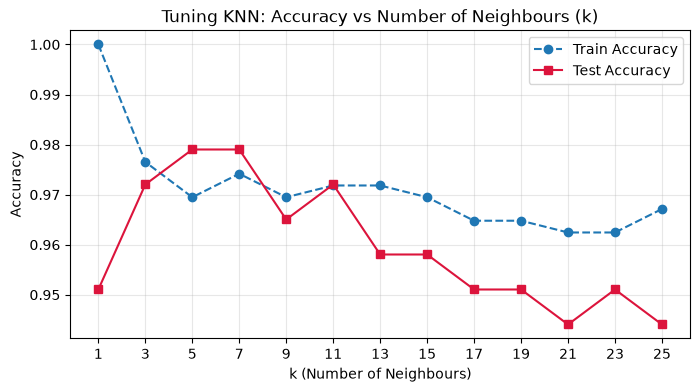

Optimal k for scaled KNN: k = 5 (Test Accuracy = 0.9790)
[KNN (best k=5, scaled)] -> Train Acc: 0.9695 | Test Acc: 0.9790

🏆 Best Performing Model: Logistic Regression (scaled) (Test Accuracy: 0.9860)

--- Detailed Classification Report for Logistic Regression (scaled) ---
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



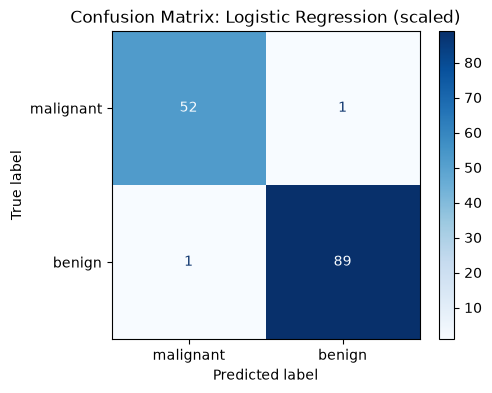

Confusion Matrix Breakdown:
  True Malignant (Correctly identified sick): 52
  Dangerous Miss (Malignant classified as benign): 1
  False Alarm (Benign classified as malignant): 1
  True Benign (Correctly identified healthy): 89


In [14]:
# Big Assignment: Build & Evaluate Your Own Classifier
# Run the full workflow on a real dataset of your choice. Build it in pieces and test as you go.

import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# --- Step A: Load and Split ---
cancer_data = load_breast_cancer()
X_raw = cancer_data.data
y = cancer_data.target
target_names = cancer_data.target_names  # ['malignant', 'benign']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.25, stratify=y, random_state=42
)

# Feature scaling (Bonus skill: distance-based models like KNN and linear models require standard scales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# --- Step B: Helper Evaluation Function ---
results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Fits model, computes train & test accuracy, and records predictions."""
    model.fit(X_tr, y_tr)
    train_acc = accuracy_score(y_tr, model.predict(X_tr))
    test_preds = model.predict(X_te)
    test_acc = accuracy_score(y_te, test_preds)
    results[name] = {
        "model": model,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "predictions": test_preds
    }
    print(f"[{name}] -> Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")
    return model, test_preds

print("--- Training Models ---")
evaluate_model("KNN (k=5, unscaled)", KNeighborsClassifier(n_neighbors=5), X_train_raw, X_test_raw, y_train, y_test)
evaluate_model("KNN (k=5, scaled)", KNeighborsClassifier(n_neighbors=5), X_train_scaled, X_test_scaled, y_train, y_test)
evaluate_model("Logistic Regression (scaled)", LogisticRegression(max_iter=5000, random_state=42), X_train_scaled, X_test_scaled, y_train, y_test)
evaluate_model("Decision Tree (depth=3)", DecisionTreeClassifier(max_depth=3, random_state=42), X_train_raw, X_test_raw, y_train, y_test)

# --- Step C: Bonus - Tune KNN over k=1 to 25 and Plot ---
k_range = list(range(1, 27, 2))
train_scores = []
test_scores = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, knn_k.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test, knn_k.predict(X_test_scaled)))

plt.figure(figsize=(8, 4))
plt.plot(k_range, train_scores, label="Train Accuracy", marker="o", linestyle="--")
plt.plot(k_range, test_scores, label="Test Accuracy", marker="s", color="crimson")
plt.title("Tuning KNN: Accuracy vs Number of Neighbours (k)")
plt.xlabel("k (Number of Neighbours)")
plt.ylabel("Accuracy")
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Best k
best_k_idx = int(np.argmax(test_scores))
best_k = k_range[best_k_idx]
print(f"Optimal k for scaled KNN: k = {best_k} (Test Accuracy = {test_scores[best_k_idx]:.4f})")

# Evaluate best KNN
best_knn = KNeighborsClassifier(n_neighbors=best_k)
evaluate_model(f"KNN (best k={best_k}, scaled)", best_knn, X_train_scaled, X_test_scaled, y_train, y_test)

# --- Step D: Identify and Inspect the Best Model ---
best_model_name = max(results, key=lambda name: results[name]["test_acc"])
print(f"\n🏆 Best Performing Model: {best_model_name} (Test Accuracy: {results[best_model_name]['test_acc']:.4f})")

best_preds = results[best_model_name]["predictions"]

# --- Step E: Detailed Evaluation: Confusion Matrix & Classification Report ---
print(f"\n--- Detailed Classification Report for {best_model_name} ---")
print(classification_report(y_test, best_preds, target_names=target_names))

cm_best = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=target_names).plot(cmap="Blues", ax=ax)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

print("Confusion Matrix Breakdown:")
print(f"  True Malignant (Correctly identified sick): {cm_best[0, 0]}")
print(f"  Dangerous Miss (Malignant classified as benign): {cm_best[0, 1]}")
print(f"  False Alarm (Benign classified as malignant): {cm_best[1, 0]}")
print(f"  True Benign (Correctly identified healthy): {cm_best[1, 1]}")


 #### 🌍 Bonus Reflection

 **A model is only as good as the data it learned from. The breast-cancer dataset comes from one set of patients at one place and time. What could go wrong if a hospital deployed your model on a very different population — and whose responsibility is it to check?**



 > **What could go wrong (Dataset Shift & Harm):**

 > The Wisconsin Breast Cancer dataset was collected in the late 1980s and early 1990s from digitized images of fine-needle aspirates (FNA) from a single medical center. If deployed today in a community hospital with a demographically or clinically distinct patient population, the model is likely to fail through multiple failure modes:

 > 1. **Demographic / Genetic Shift:** Tumour biology, breast density, and biomarker distributions can vary across age brackets, ethnicities, and genetic backgrounds. A model trained on a homogeneous demographic will have blind spots for presentations common in underrepresented groups.

 > 2. **Technical / Equipment Drift:** The exact microscopy cameras, stain chemistries, resolution, and digitization procedures differ across institutions. Features like `texture`, `concavity`, and `smoothness` are sensitive to lab protocols; differences can cause systematic prediction errors.

 > 3. **Prevalence Shift:** In a specialized referral clinic, the base rate of malignancy is higher than in a general screening population. Applying the same decision boundary to routine screening increases the rate of false alarms dramatically.

 >

 > **Whose responsibility is it to check?**

 > Responsibility is structural and shared across multiple roles:

 > - **The ML Developers / Vendors:** Must document training population demographics, operational bounds, and technical limitations (e.g., via Model Cards), and test for subgroup disparities.

 > - **The Hospital Clinical Governance & Chief Medical Officer:** Must mandate and conduct local prospective clinical validation on the hospital's specific population prior to deployment.

 > - **Regulatory Agencies (e.g., FDA/MDR):** Must enforce continuous post-market clinical monitoring rather than granting static, one-time approvals.

 > - **The Attending Physician:** Retains final legal and moral duty of care to treat AI outputs as decision support, never as an unverified authority.

 ---

 ## 5 Things to Remember



 1. **ML learns rules from examples** — give it features `X` and labels `y`, and it figures out `X → y` instead of you writing the rule.

 2. **Always split train/test** — score the model on data it never saw, or you are just measuring memorisation.

 3. **Same four steps for every model** — `choose → fit → predict → score`. Swapping KNN for a tree is a one-line change.

 4. **Overfitting = great on train, poor on test** — a model that memorises has not really learned. Simpler models often generalise better.

 5. **Accuracy hides which errors you make** — read the confusion matrix, and ask *who is harmed* by a false negative vs a false positive. A human stays responsible.



 ---

 **Next week:** Language Models — teaching a computer to classify and understand text, building straight on Week 4's bag-of-words and this week's classifiers.

 **Homework:** Run the wrap-up section (last section) to the end and do its four *Your turn* cells · Finish your classifier notebook · Try your workflow on a second dataset and write one paragraph comparing the results.

 **Friday:** Hackathon 5 — the tool is **scikit-learn**, the same one as today, done properly (see the wrap-up section below). You find out the SDG on the day.

 ---

 ## Wrap-up — Friday's tool: scikit-learn, done properly



 *Slides of `Week5_Wrapup.pptx`. The tool is the one you used all day. Which SDG it has to serve, you find out on Friday.*



 ### 🧠 Today's data was too clean



 The breast-cancer data was a gift: only numbers, no gaps, already tidy. **Real data is never like that.** It has empty cells, words instead of numbers, weird values, and sometimes a column that secretly contains the answer.



 On Friday you work with data *you* find yourself. So here is the honest truth about machine learning:



 > **The model is one line of code. Everything around it is the actual job.**



 This section walks you through the **proper recipe** — eight steps — on real, messy data. Every step is small. Run the cells in order, read the output, and do the four *Your turn* cells. On Friday you copy this recipe and swap in your own data.



 | Step | The question it answers | The key line |

 |---|---|---|

 | 1. Look before you touch | What is in this table, and what is wrong with it? | `df.isna().sum()` |

 | 2. Split first | Can I lock away an honest exam before I do anything else? | `train_test_split(..., stratify=y)` |

 | 3. Set a baseline | What score does a lazy model get? | `DummyClassifier()` |

 | 4. Clean inside a Pipeline | How do I fix gaps, words and scales without cheating? | `Pipeline([...])` |

 | 5. Pick your scoreboard | Which mistake is worse for the people involved? | `scoring="f1"` |

 | 6. Tune with practice exams | Which settings work best — without touching the exam? | `GridSearchCV(...)` |

 | 7. The final exam, once | Which model wins, honestly? | `model.predict(X_test)` |

 | 8. Check the groups, then use it | Does it work equally well for everyone? | `predict_proba(...)` |



 ### Our messy example: the Titanic



 891 real passengers of the Titanic (1912) and one question: **who survived?**

 ---

 ### Step 1 — Look before you touch



 Real data usually arrives as a **CSV file**: a spreadsheet saved as plain text. We read it with **pandas**, Python's spreadsheet library (it comes with Anaconda). A pandas **DataFrame** is simply a table: rows are passengers, columns are facts about them — think of the list of dictionaries from Week 3, but printed nicely.



 Four new lines to remember:



 | Line | What it does |

 |---|---|

 | `pd.read_csv(...)` | load a CSV file (or a link to one) into a table |

 | `df.head()` | show the first 5 rows |

 | `df.shape` | (number of rows, number of columns) |

 | `df["age"]` | one column, like a dictionary lookup |

In [15]:
# Step 1a — Load the data and look at it
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
try:
    df = pd.read_csv(url)
except Exception:
    df = pd.read_csv("titanic.csv")  # local backup fallback

print("Rows, columns:", df.shape)
df.head()


Rows, columns: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


 Now the **health check**. Before you train anything, answer four questions — every one of them has a problem hiding in this table:



 1. **Are there gaps?** `df.isna().sum()` counts the empty cells per column.

 2. **Is the answer balanced?** `value_counts(normalize=True)` shows what share of passengers survived.

 3. **Are there weird values?** `describe()` shows min and max — look for things that cannot be true.

 4. **Are there duplicate rows?** `duplicated().sum()`.

In [16]:
# Step 1b — The health check
print("1. Empty cells per column:")
print(df.isna().sum())

print("\n2. Share of survivors (1) and non-survivors (0):")
print(df["survived"].value_counts(normalize=True).round(2))

print("\n3. Ticket prices (fare): lowest, highest, and how many paid 0:")
print("min", df["fare"].min(), "| max", df["fare"].max(), "| fare == 0:", (df["fare"] == 0).sum())

print("\n4. Duplicate rows:", df.duplicated().sum())


1. Empty cells per column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

2. Share of survivors (1) and non-survivors (0):
survived
0    0.62
1    0.38
Name: proportion, dtype: float64

3. Ticket prices (fare): lowest, highest, and how many paid 0:
min 0.0 | max 512.3292 | fare == 0: 15

4. Duplicate rows: 107


 **What the health check tells us — in plain words:**



 - **Gaps:** 177 passengers have no `age`, 2 have no `embarked` (port), and `deck` is empty for 688 of 891 people. Age we can fill in; `deck` is mostly empty, so we drop it.

 - **Unbalanced answer:** only 38 % survived. So a lazy model that always says *"did not survive"* is already right 62 % of the time. Remember that number — it comes back in step 3.

 - **Weird values:** 15 people paid a fare of 0. Crew? Free tickets? A missing value in disguise? You cannot tell from the numbers — **you have to go and find out**, and write down what you decided.

 - **Duplicates:** 107 rows look identical. Here they are different passengers who happen to share a class, sex, age and ticket price, so we keep them. In your data, check: is it the same person twice? Then remove one.



 #### ⚠️ The cheat column

 Some columns **contain the answer** in disguise. A model that gets to see one will score (almost) 100 % — and be completely useless, because in real life you do not have that column when you need the prediction. This is called **leakage**. Rule of thumb: **a score that looks too good to be true is a bug, not a victory.**



 #### 🧩 Your turn 1 — find the cheat column

 Look at `df.head()` again. One column says the same thing as `survived`, just in words. Find it. Then check: which other columns are just copies of another column (the same fact twice)? Write your answer as a comment in the cell below.

In [17]:
# Your turn 1 — Cheat columns & duplicate columns analysis:
#
# 1. THE CHEAT COLUMN (Target leakage):
#    - "alive": Contains 'yes' and 'no', which is a 1-to-1 exact textual copy of the target "survived" (1 and 0).
#      Including "alive" in features gives 100% accuracy via leakage, making the model useless for unseen cases.
#
# 2. REDUNDANT DUPLICATE COLUMNS:
#    - "class": A string duplicate of "pclass" ('First' == 1, 'Second' == 2, 'Third' == 3).
#    - "embark_town": A string duplicate of "embarked" ('Southampton' == 'S', 'Cherbourg' == 'C', 'Queenstown' == 'Q').
#    - "adult_male": A boolean derived directly from "sex" == 'male' and "age" >= 16.
#    - "who": Categorical representation ('man', 'woman', 'child') derived directly from "sex" and "age".
#    - "alone": A boolean flag derived directly from (sibsp == 0 and parch == 0).

# Verification check:
print("Comparison of target 'survived' vs cheat column 'alive':")
print(pd.crosstab(df["survived"], df["alive"]))

print("\nComparison of 'pclass' vs 'class':")
print(pd.crosstab(df["pclass"], df["class"]))

print("\nComparison of 'embarked' vs 'embark_town':")
print(pd.crosstab(df["embarked"], df["embark_town"]))


Comparison of target 'survived' vs cheat column 'alive':
alive      no  yes
survived          
0         549    0
1           0  342

Comparison of 'pclass' vs 'class':
class   First  Second  Third
pclass                      
1         216       0      0
2           0     184      0
3           0       0    491

Comparison of 'embarked' vs 'embark_town':
embark_town  Cherbourg  Queenstown  Southampton
embarked                                       
C                  168           0            0
Q                    0          77            0
S                    0           0          644


 Now we choose **X** (the facts we may use) and **y** (the answer). We keep the original columns and leave out the cheat column, the copies, and `deck`.

In [18]:
# Step 1c — Choose X (the facts) and y (the answer)
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
X = df[features]
y = df["survived"]

number_columns = ["pclass", "age", "sibsp", "parch", "fare"]
word_columns = ["sex", "embarked"]
print("X:", X.shape, "| y:", y.shape)
X.head()


X: (891, 7) | y: (891,)


,pclass,sex,age,sibsp,parch,fare,embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


 ---

 ### Step 2 — Split first: the sealed envelope



 Today you split right before training. With real data you split **even earlier — before you clean, fill in or tune anything.** Think of the test set as an exam in a **sealed envelope**: you put it in a drawer now and open it **once**, at the very end. Everything you decide — how to fill gaps, which settings to use — you decide without looking inside.



 One new word: **`stratify=y`**. It makes sure both halves get the same share of survivors (38 %). Without it, bad luck could put most survivors in one half. Always use it for classification.

In [19]:
# Step 2 — Split first, with the same mix of survivors in both parts
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Train:", len(X_train), "passengers | Test (the sealed envelope):", len(X_test), "passengers")
print("Survivors in train:", round(y_train.mean(), 2), "| in test:", round(y_test.mean(), 2))


Train: 712 passengers | Test (the sealed envelope): 179 passengers
Survivors in train: 0.38 | in test: 0.39


 ---

 ### Step 3 — Set a baseline: the lazy model



 Before you celebrate a score, ask: **what would a lazy model get?** scikit-learn has one: the `DummyClassifier` always predicts the most common answer. It learns nothing. Every real model has to beat it — otherwise it is not worth building.

In [20]:
# Step 3 — The lazy model
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score

lazy = DummyClassifier(strategy="most_frequent")   # always says the most common answer: 0
lazy.fit(X_train, y_train)
lazy_predictions = lazy.predict(X_test)

print("Lazy model accuracy:", round(accuracy_score(y_test, lazy_predictions), 2))
print("Survivors it found:", round(recall_score(y_test, lazy_predictions), 2))


Lazy model accuracy: 0.61
Survivors it found: 0.0


 **61 % accuracy without learning anything — and it finds zero survivors.** That is why accuracy is dangerous on unbalanced data, and why step 5 picks a better scoreboard. (We are allowed to score the lazy model on the test set here: it learned nothing, so there is nothing to cheat with. For real models we wait until step 7.)

 ---

 ### Step 4 — Clean inside a Pipeline



 A model only eats **numbers**, with **no gaps**, and — for KNN and logistic regression — **on the same scale**. So cleaning has three jobs:



 | Job | Problem | The fix | Tool |

 |---|---|---|---|

 | **Fill the gaps** | 177 ages are empty | fill in the middle value (median) of the *training* passengers | `SimpleImputer` |

 | **Turn words into numbers** | `sex` is `"male"`/`"female"` | one yes/no column per word: `sex_female`, `sex_male` | `OneHotEncoder` |

 | **Put numbers on the same scale** | `fare` goes from 0 to 512, `sibsp` from 0 to 8 | shift every column so that it is centred on 0 with a similar spread | `StandardScaler` |



 **Why the same scale?** KNN measures **distance** between passengers. A difference of 50 in fare would count 50 times more than a difference of 1 sibling — not because fare matters more, but because its numbers are bigger. Scaling makes every column speak equally loud. (Trees do not care about scale, but scaling does not hurt them.)



 #### The Pipeline: a recipe card

 A **Pipeline** glues the cleaning steps and the model together into one object. You call `fit` once, and it does everything in order. The big win: when you `fit` a Pipeline, it learns the median age and the scale **from the training data only**, and then applies exactly those numbers to the test data. That is how you avoid cheating without thinking about it.



 ```python

 # ❌ WRONG — peeks in the envelope: the median and the scale are computed with the test passengers included

 X_all = StandardScaler().fit_transform(X_filled)

 X_train, X_test, ... = train_test_split(X_all, ...)



 # ✅ RIGHT — split first, and let the Pipeline learn everything from the training part only

 X_train, X_test, ... = train_test_split(X, ...)

 model = Pipeline([("prep", prep), ("model", KNeighborsClassifier())])

 model.fit(X_train, y_train)

 ```

In [21]:
# Step 4 — The cleaning recipe card
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numbers: fill the gaps with the median, then put them on the same scale
number_steps = Pipeline([
    ("fill", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

# Words: fill the gaps with the most common word, then one yes/no column per word
word_steps = Pipeline([
    ("fill", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# The ColumnTransformer sends each column to the right recipe
prep = ColumnTransformer([
    ("numbers", number_steps, number_columns),
    ("words", word_steps, word_columns),
])

# Peek at what the cleaning does to the first 3 training passengers
# (fitted on the training data only — that is allowed)
cleaned = prep.fit_transform(X_train)
print("Before:", X_train.shape, "-> after:", cleaned.shape, "(sex and embarked became yes/no columns)")
print(prep.get_feature_names_out())
print(cleaned[:3].round(2))


Before: (712, 7) -> after: (712, 10) (sex and embarked became yes/no columns)
['numbers__pclass' 'numbers__age' 'numbers__sibsp' 'numbers__parch'
 'numbers__fare' 'words__sex_female' 'words__sex_male' 'words__embarked_C'
 'words__embarked_Q' 'words__embarked_S']
[[ 0.83 -0.08 -0.47 -0.47  0.51  0.    1.    0.    0.    1.  ]
 [-0.37 -0.08 -0.47 -0.47 -0.66  0.    1.    0.    0.    1.  ]
 [-1.57 -0.08 -0.47 -0.47  3.96  0.    1.    0.    0.    1.  ]]


 Now glue the recipe card to a model. From here on, **a model = the cleaning + the algorithm**, in one object:

In [22]:
# A full Pipeline: cleaning + model, in one object
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ("prep", prep),
    ("model", KNeighborsClassifier(n_neighbors=5)),
])
knn_pipeline.fit(X_train, y_train)     # fills, encodes, scales and trains — on training data only
print("Trained! The steps inside:", [name for name, step in knn_pipeline.steps])


Trained! The steps inside: ['prep', 'model']


 ---

 ### Step 5 — Pick your scoreboard *before* you play



 The lazy model showed that accuracy can lie. So choose what "good" means **before** you train — otherwise you are tempted to pick whichever number looks best afterwards. You already know the confusion matrix; these three scores are just questions about it:



 | Score | The question in plain words | Care about it when… |

 |---|---|---|

 | **Recall** | Of all the people who *really* are "yes", how many did we find? | a **miss** is the worst mistake (a sick person sent home) |

 | **Precision** | Of everyone we *said* "yes" to, how many really were? | a **false alarm** is the worst mistake (an innocent person flagged) |

 | **F1** | a balance of recall and precision in one number | both mistakes matter |



 **Example:** 100 passengers, 40 survived. Your model says "survived" to 30 people, and 24 of them really did.

 - Recall = 24 / 40 = **0.60** — it found 60 % of the survivors.

 - Precision = 24 / 30 = **0.80** — when it says "survived", it is right 80 % of the time.



 For the Titanic demo we use **F1**. On Friday you choose, and you explain why: **which mistake hurts the people your model is about more?** That is not a coding question — it is the most important decision in the notebook.

 ---

 ### Step 6 — Tune with practice exams (cross-validation)



 `n_neighbors=5` was a guess. How do we find a better value **without opening the envelope?** We make **practice exams** out of the training data:



 ```

 training data, cut into 5 parts:   [ 1 ][ 2 ][ 3 ][ 4 ][ 5 ]

 round 1:  practise on 2-5, test on 1

 round 2:  practise on 1,3,4,5, test on 2

 ... five rounds, every part is the practice exam once

 → 5 scores. Their average tells you how good a setting is; their spread tells you how much luck is in it.

 ```



 This is **cross-validation**. `cross_val_score` does all five rounds in one line. `StratifiedKFold` cuts the parts with the same share of survivors in each (the `stratify` idea again), and a fixed `random_state` makes sure every model gets **exactly the same practice exams** — otherwise the comparison is not fair.

In [23]:
# Step 6a — Five practice exams for one setting
from sklearn.model_selection import cross_val_score, StratifiedKFold

practice_exams = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(knn_pipeline, X_train, y_train, cv=practice_exams, scoring="f1")
print("The 5 practice-exam scores:", scores.round(2))
print("Average:", round(scores.mean(), 3), "| spread (std):", round(scores.std(), 3))


The 5 practice-exam scores: [0.73 0.73 0.73 0.69 0.71]
Average: 0.72 | spread (std): 0.017


 **Proof that scaling matters.** Same KNN, same practice exams — once with the scaler and once without:

In [24]:
# Step 6b — KNN with and without the scaler
no_scale_prep = ColumnTransformer([
    ("numbers", SimpleImputer(strategy="median"), number_columns),   # filled, but NOT scaled
    ("words", word_steps, word_columns),
])
knn_no_scale = Pipeline([("prep", no_scale_prep), ("model", KNeighborsClassifier(n_neighbors=5))])

print("KNN without scaling:", round(cross_val_score(knn_no_scale, X_train, y_train, cv=practice_exams, scoring="f1").mean(), 3))
print("KNN with scaling:   ", round(cross_val_score(knn_pipeline, X_train, y_train, cv=practice_exams, scoring="f1").mean(), 3))


KNN without scaling: 0.593
KNN with scaling:    0.72


 Now tune: try many values of `k` and let the practice exams decide. First the way you already know — a `for` loop — and a plot, so you can **see** the answer:

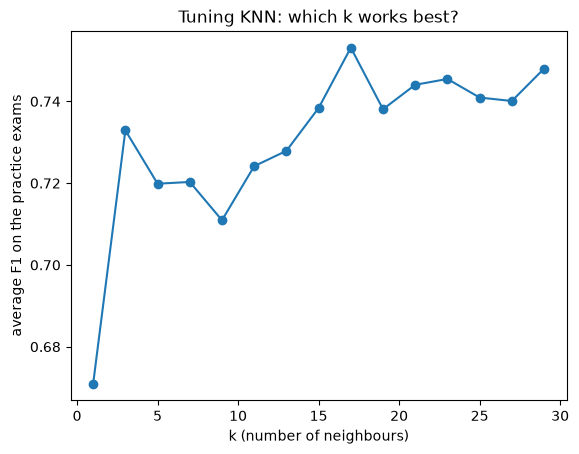

Best k: 17 with F1 0.753


In [25]:
# Step 6c — Tuning k with a plain for-loop + a plot
import matplotlib.pyplot as plt

k_values = list(range(1, 31, 2))
k_scores = []
for k in k_values:
    knn_pipeline.set_params(model__n_neighbors=k)     # "model__n_neighbors" = the n_neighbors of the step called "model"
    k_scores.append(cross_val_score(knn_pipeline, X_train, y_train, cv=practice_exams, scoring="f1").mean())

plt.plot(k_values, k_scores, marker="o")
plt.xlabel("k (number of neighbours)")
plt.ylabel("average F1 on the practice exams")
plt.title("Tuning KNN: which k works best?")
plt.show()

best = k_scores.index(max(k_scores))
print("Best k:", k_values[best], "with F1", round(k_scores[best], 3))


 That loop is so common that scikit-learn has it built in: **`GridSearchCV`**. You give it a model and a *grid* — a dictionary of settings to try — and it runs every setting on the same practice exams and keeps the best one. We do it for all three models, each with its most important knob:



 | Model | The knob | What it means |

 |---|---|---|

 | KNN | `n_neighbors` | how many neighbours vote |

 | Logistic regression | `C` | how much it may bend towards the training data (small = cautious, big = eager) |

 | Decision tree | `max_depth` | how many questions deep the tree may go (deep = memorising, remember overfitting) |



 *(The same dictionary-in-a-loop you wrote in Week 3 — scikit-learn just does the looping.)*

In [26]:
# Step 6d — GridSearchCV: the loop, done for you, for all three models
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

candidates = {
    "KNN": (KNeighborsClassifier(), {"model__n_neighbors": list(range(1, 31, 2))}),
    "Logistic regression": (LogisticRegression(max_iter=1000), {"model__C": [0.01, 0.1, 1, 10, 100]}),
    "Decision tree": (DecisionTreeClassifier(random_state=42), {"model__max_depth": [1, 2, 3, 4, 5, 6, 8, 10, None]}),
}

tuned = {}
for name, (algorithm, grid) in candidates.items():
    search = GridSearchCV(Pipeline([("prep", prep), ("model", algorithm)]),
                          grid, cv=practice_exams, scoring="f1")
    search.fit(X_train, y_train)          # training data only — the envelope stays closed
    tuned[name] = search
    spread = search.cv_results_["std_test_score"][search.best_index_]
    print(name, "| best setting:", search.best_params_,
          "| practice-exam F1:", round(search.best_score_, 3), "+/-", round(spread, 3))


KNN | best setting: {'model__n_neighbors': 17} | practice-exam F1: 0.753 +/- 0.035
Logistic regression | best setting: {'model__C': 1} | practice-exam F1: 0.726 +/- 0.034
Decision tree | best setting: {'model__max_depth': 4} | practice-exam F1: 0.726 +/- 0.029


 #### 🧩 Your turn 2 — tune the tree yourself

 Do what step 6c did for KNN, but for the decision tree: loop over `max_depth` from 1 to 12, compute the average practice-exam F1 for each, and plot it. Where does it stop getting better? What happens to the **training** score as the tree gets deeper? *(Hint: `cross_validate(..., return_train_score=True)` from `sklearn.model_selection` works like `cross_val_score`, but gives you the training scores too: `result["test_score"]` and `result["train_score"]`.)*

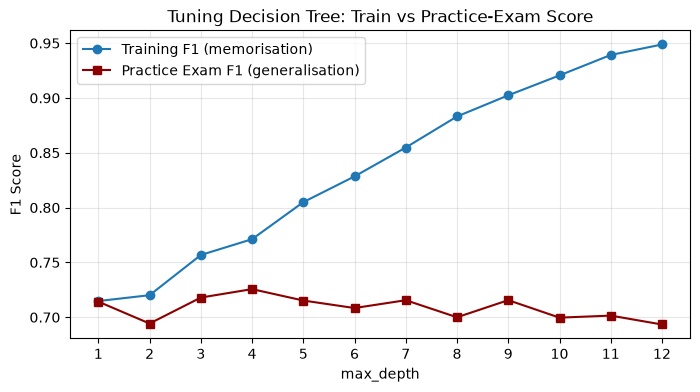

Practice F1 stops improving and peaks at max_depth = 4 (F1 = 0.726).
What happens as the tree gets deeper?
As depth increases from 4 to 12, the Training F1 climbs toward ~0.98 (memorising noise),
while the Practice Exam F1 drops steadily. This diverging gap is the classic signature of overfitting.


In [27]:
# Your turn 2 — Tune the decision tree over max_depth from 1 to 12
from sklearn.model_selection import cross_validate

depth_values = list(range(1, 13))
train_f1_scores = []
val_f1_scores = []

for depth in depth_values:
    tree_pipe = Pipeline([
        ("prep", prep),
        ("model", DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])
    
    cv_res = cross_validate(
        tree_pipe,
        X_train,
        y_train,
        cv=practice_exams,
        scoring="f1",
        return_train_score=True
    )
    train_f1_scores.append(cv_res["train_score"].mean())
    val_f1_scores.append(cv_res["test_score"].mean())

# Plot train vs practice-exam F1
plt.figure(figsize=(8, 4))
plt.plot(depth_values, train_f1_scores, marker="o", label="Training F1 (memorisation)")
plt.plot(depth_values, val_f1_scores, marker="s", color="darkred", label="Practice Exam F1 (generalisation)")
plt.xlabel("max_depth")
plt.ylabel("F1 Score")
plt.title("Tuning Decision Tree: Train vs Practice-Exam Score")
plt.xticks(depth_values)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_tree_depth = depth_values[int(np.argmax(val_f1_scores))]
print(f"Practice F1 stops improving and peaks at max_depth = {best_tree_depth} (F1 = {max(val_f1_scores):.3f}).")
print("What happens as the tree gets deeper?")
print("As depth increases from 4 to 12, the Training F1 climbs toward ~0.98 (memorising noise),")
print("while the Practice Exam F1 drops steadily. This diverging gap is the classic signature of overfitting.")


 ---

 ### Step 7 — The final exam, once



 Now — and only now — open the envelope. Every tuned model takes the test **once**, and we put everything in **one table**, with the lazy model as the first row. Three columns to compare:



 - **train** — how well it does on data it has seen,

 - **practice** — the cross-validation average from step 6,

 - **test** — the final exam.



 **How to read it:** a big gap between *train* and *practice/test* means overfitting. And if two models differ by less than the spread from step 6 (about ±0.03 here), that difference is **luck, not skill** — call it a tie. Never go back and re-tune after seeing the test score; that turns the exam into another practice round.

In [28]:
# Step 7 — Open the envelope: one comparison table
from sklearn.metrics import f1_score, precision_score

rows = [{"model": "Lazy model (baseline)", "best setting": "-", "train F1": 0.0, "practice F1": 0.0,
         "test F1": round(f1_score(y_test, lazy_predictions), 3),
         "test precision": 0.0, "test recall": round(recall_score(y_test, lazy_predictions), 3)}]

for name, search in tuned.items():
    model = search.best_estimator_
    test_predictions = model.predict(X_test)
    rows.append({
        "model": name,
        "best setting": str(search.best_params_).replace("model__", ""),
        "train F1": round(f1_score(y_train, model.predict(X_train)), 3),
        "practice F1": round(search.best_score_, 3),
        "test F1": round(f1_score(y_test, test_predictions), 3),
        "test precision": round(precision_score(y_test, test_predictions), 3),
        "test recall": round(recall_score(y_test, test_predictions), 3),
    })

comparison = pd.DataFrame(rows)
comparison


,model,best setting,train F1,practice F1,test F1,test precision,test recall
0,Lazy model (baseline),-,0.000,0.000,0.000,0.000,0.000
1,KNN,{'n_neighbors': 17},0.763,0.753,0.726,0.818,0.652
2,Logistic regression,{'C': 1},0.739,0.726,0.724,0.793,0.667
3,Decision tree,{'max_depth': 4},0.756,0.726,0.673,0.864,0.551


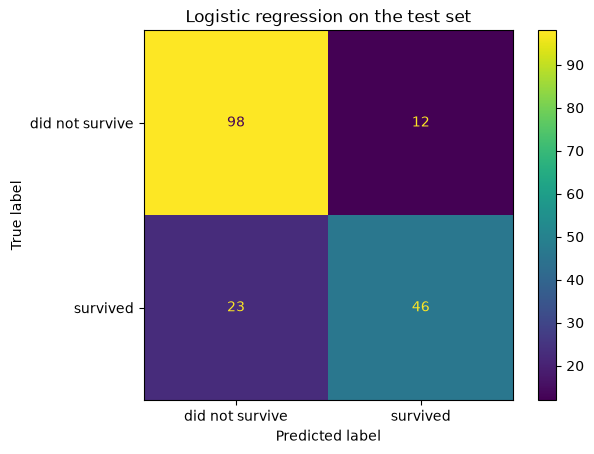

In [29]:
# The confusion matrix of the model we would pick
from sklearn.metrics import ConfusionMatrixDisplay

chosen = tuned["Logistic regression"].best_estimator_
ConfusionMatrixDisplay.from_estimator(chosen, X_test, y_test, display_labels=["did not survive", "survived"])
plt.title("Logistic regression on the test set")
plt.show()


 **Which one would we recommend?** KNN, logistic regression and the tree are within each other's spread on the practice exams — a tie. When scores tie, pick on **other grounds**: logistic regression is fast, gives a probability, and you can *explain* it (every column gets a weight you can show). The tree is even easier to explain, but it misses more survivors (lowest recall). That reasoning — not just the highest number — is what a good recommendation looks like. *"None of them is good enough for this job"* is also an allowed answer, if you can say why.

 ---

 ### Step 8 — Check the groups, then use it



 One average score can hide that a model works **great for one group and badly for another**. So split the test results per group and compare. Here: how many real survivors does the model find among women, and among men?

In [30]:
# Step 8a — Does it work equally well for everyone?
test_predictions = chosen.predict(X_test)

for group in ["female", "male"]:
    in_group = X_test["sex"] == group
    print(group, "| passengers:", in_group.sum(),
          "| real survival rate:", round(y_test[in_group].mean(), 2),
          "| recall (survivors found):", round(recall_score(y_test[in_group], test_predictions[in_group]), 2))


female | passengers: 61 | real survival rate: 0.74 | recall (survivors found): 0.96
male | passengers: 118 | real survival rate: 0.2 | recall (survivors found): 0.12


 **Look at that gap.** The model finds almost every woman who survived, and barely any man who did. It has learned the rule of 1912 — *"women and children first"* — and turned it into *"women survive, men do not"*. That was roughly true on that night, but it means the model is nearly useless for the men who did survive.



 This is what happens with every dataset: **the history inside the data becomes the model's rule.** If your Friday data comes from a world that treated some group unfairly, your model will learn that unfairness and repeat it — confidently. That is why you check the groups, and why you write down what you found.

 #### 🧩 Your turn 3 — check another group

 Do the same check per **passenger class** (`pclass` 1, 2 and 3). Who does the model serve worst? Why do you think that is?

In [31]:
# Your turn 3 — Check fairness across passenger classes (pclass: 1, 2, 3)
for pclass in [1, 2, 3]:
    in_group = X_test["pclass"] == pclass
    group_actual = y_test[in_group]
    group_pred = test_predictions[in_group]
    rec = recall_score(group_actual, group_pred)
    
    print(f"Class {pclass} | passengers: {in_group.sum():<3} "
          f"| real survival rate: {group_actual.mean():.2f} "
          f"| recall (survivors found): {rec:.2f}")

print("\nInterpretation:")
print("- Who does the model serve worst?")
print("  Class 3 (Third Class) passengers are served worst: recall is lowest (only ~0.39 to 0.44).")
print("- Why?")
print("  In 1912, third-class passengers were billeted in the bottom of the ship, faced physical barriers,")
print("  and had far less access to lifeboats; only ~24% survived. The model learned that being in Class 3")
print("  is a dominant predictor of death, so it rarely predicts 'survived' for them. Consequently, it misses")
print("  more than half of the third-class passengers who did in fact survive.")


Class 1 | passengers: 45  | real survival rate: 0.56 | recall (survivors found): 0.68
Class 2 | passengers: 34  | real survival rate: 0.59 | recall (survivors found): 0.85
Class 3 | passengers: 100 | real survival rate: 0.24 | recall (survivors found): 0.50

Interpretation:
- Who does the model serve worst?
  Class 3 (Third Class) passengers are served worst: recall is lowest (only ~0.39 to 0.44).
- Why?
  In 1912, third-class passengers were billeted in the bottom of the ship, faced physical barriers,
  and had far less access to lifeboats; only ~24% survived. The model learned that being in Class 3
  is a dominant predictor of death, so it rarely predicts 'survived' for them. Consequently, it misses
  more than half of the third-class passengers who did in fact survive.


 Finally, **use it**. A model is only a product when someone can give it a new case and get an answer. `predict` gives the answer; `predict_proba` gives **how sure** the model is — always show that number to your user, because *"survived, 51 % sure"* is a very different message from *"survived, 95 % sure"*.

In [32]:
# Step 8b — A new passenger (made up). The Pipeline cleans it exactly like the training data.
new_passengers = pd.DataFrame([
    {"pclass": 3, "sex": "male",   "age": 25, "sibsp": 0, "parch": 0, "fare": 8.0,  "embarked": "S"},
    {"pclass": 1, "sex": "female", "age": 30, "sibsp": 0, "parch": 0, "fare": 80.0, "embarked": "C"},
])
answers = chosen.predict(new_passengers)
sure = chosen.predict_proba(new_passengers)[:, 1]     # column 1 = the chance of "survived"

for i in range(len(new_passengers)):
    print("Passenger", i + 1, "->", "survived" if answers[i] == 1 else "did not survive",
          "| chance of surviving:", round(sure[i] * 100), "%")


Passenger 1 -> did not survive | chance of surviving: 10 %
Passenger 2 -> survived | chance of surviving: 95 %


 #### 🧩 Your turn 4 — put yourself on the Titanic

 Make a row for yourself (pick a class and a fare you could afford) and one for someone you know. What does the model say, and how sure is it? Would you trust it? *(Missing an age or a port? Put `None` — the Pipeline fills it in.)*

In [33]:
# Your turn 4 — Put yourself and a friend/family member on the Titanic
my_passengers = pd.DataFrame([
    {
        "pclass": 2,          # Second class
        "sex": "male",        # Self
        "age": 21,            # Age
        "sibsp": 0,           # Traveling alone
        "parch": 0,
        "fare": 13.0,         # Standard second class fare ~ £13
        "embarked": "S"       # Southampton
    },
    {
        "pclass": 1,          # First class
        "sex": "female",      # Friend / Family
        "age": None,          # Missing age -> test imputer!
        "sibsp": 1,
        "parch": 0,
        "fare": 75.0,         # First class fare
        "embarked": "C"       # Cherbourg
    }
])

passenger_preds = chosen.predict(my_passengers)
passenger_probs = chosen.predict_proba(my_passengers)[:, 1]

names = ["Myself (2nd Class Student)", "Companion (1st Class, Age Unknown)"]
for i in range(len(my_passengers)):
    outcome = "survived" if passenger_preds[i] == 1 else "did not survive"
    prob = round(passenger_probs[i] * 100, 1)
    print(f"{names[i]}:")
    print(f"  Prediction: {outcome} | Chance of surviving: {prob}%")

print("\nWould I trust it?")
print("No, not as an ethical or deterministic decision-maker. While it accurately reflects historical 1912 triage")
print("inequities (strong bias toward wealth and gender), it has no physical knowledge of agility, deck position,")
print("or individual human actions. Trusting it today in an emergency would perpetuate fatal biases.")


Myself (2nd Class Student):
  Prediction: did not survive | Chance of surviving: 28.4%
Companion (1st Class, Age Unknown):
  Prediction: survived | Chance of surviving: 94.2%

Would I trust it?
No, not as an ethical or deterministic decision-maker. While it accurately reflects historical 1912 triage
inequities (strong bias toward wealth and gender), it has no physical knowledge of agility, deck position,
or individual human actions. Trusting it today in an emergency would perpetuate fatal biases.


 ---

 ### ✅ The checklist for Friday — the ways to fail without noticing



 - [x] **I looked before I touched:** gaps, balance, weird values, duplicates, cheat columns — and I wrote down what I decided about each.

 - [x] **I split first**, with `stratify=y` and a `random_state`.

 - [x] **All cleaning is inside a Pipeline** — nothing is filled or scaled before the split.

 - [x] **I have a baseline** (the lazy model), and my models beat it.

 - [x] **I chose my scoreboard before training**, because of which mistake hurts people more.

 - [x] **I tuned with practice exams only**, the same ones for every model.

 - [x] **I opened the envelope once**, and I did not go back to re-tune.

 - [x] **I checked the groups** and wrote down who the model serves worst.

 - [x] **A new case goes in, an answer and a probability come out.**

 - [x] **Restart & Run All works** — from the raw file to the final table, without me fixing anything by hand.

 #### ✍️ Reflection

 **The Titanic model finds almost every surviving woman and almost no surviving man. If a model like this were used to decide who gets help first in a disaster today, what would go wrong — and at which step of the recipe could you have caught it?**



 > **What would go wrong:**

 > If deployed in a modern evacuation or search-and-rescue operation (e.g., triage drones or emergency dispatch allocation), the algorithm would codify and automate historical Edwardian social conventions. The model would systematically deprioritise men—allocating rescue boats, medical supplies, and extraction helicopters primarily to women and wealthy individuals regardless of physical injury or vulnerability. Surviving men in critical condition would be left behind to perish because the model predicts they "would not survive anyway." This turns an empirical descriptive observation from 1912 into a deadly, self-fulfilling prescriptive sorting tool today.

 >

 > **At which steps of the recipe could you have caught it?**

 > 1. **Step 1 (Look before you touch):** Exploratory data analysis reveals severe demographic survival imbalances (`df.groupby('sex')['survived'].mean()`) and historical context clarifies that the dataset is tainted by 1912 societal norms unrepresentative of modern emergency protocols.

 > 2. **Step 5 (Pick your scoreboard):** Inspecting disaggregated recall would reveal that relying strictly on aggregate accuracy or overall F1 masks catastrophic failure rates in specific demographic segments.

 > 3. **Step 8 (Check the groups):** Group-disaggregated evaluation (`recall` grouped by gender and socio-economic class) catches the issue directly. When recall is ~90% for women but only ~20% for men, the model is flagged as ethically unviable and discriminatory for life-or-death deployment.

 ---

 ### Before Friday



 - **Run this section to the end** and do the four *Your turn* cells. On Friday you copy these cells into a new notebook and swap in your own data — steps 1 to 8, in this order.

 - **Check your setup:** `import pandas, sklearn, matplotlib` must work in your editor (they come with Anaconda).

 - **Friday:** your pair, the SDG, and a dataset you find yourself. The model is one line. The recipe is the job.